In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import requests
import itertools
from scipy.interpolate import Rbf
import geopandas as gpd
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

## 1.1. Helper Functions

In [2]:
def rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    return float(np.sqrt(np.mean((a - b) ** 2)))

def corr(a, b):
    aa = np.asarray(a, float).ravel()
    bb = np.asarray(b, float).ravel()
    
    if np.std(aa) < 1e-12 or np.std(bb) < 1e-12:
        return float("nan")
        
    return float(np.corrcoef(aa, bb)[0, 1])

## 1.2. Load NYT Data
The New York Times (Covid-19) Cases and Deaths in the United States (https://www.nytimes.com/interactive/2020/us/about-coronavirus-data-maps.html)

In [3]:
STATE = "Texas" 
DATES = ["2020-07-01", "2021-01-01", "2021-09-01", "2022-01-01", "2022-05-13" ]

nyt = pd.read_csv("geo_data/us_counties_nyt.csv", dtype={"fips": "string"})
nyt["date"] = pd.to_datetime(nyt["date"])
nyt = nyt.dropna(subset=["fips"])
nyt["fips"] = nyt["fips"].astype(str).str.zfill(5)  # ensure 5-digit county code

print(f"Loaded {len(nyt):,} rows total")
print(f"Date range: {nyt['date'].min().date()} → {nyt['date'].max().date()}")

region_nyt = nyt[nyt["state"] == STATE].copy()
print(f"\n{STATE} state rows: {len(region_nyt):,}")
print(f"Counties found: {region_nyt['county'].nunique()}")
print(f"\nSample of {STATE} data:")
print(region_nyt[region_nyt["date"] == "2021-01-01"][["date","county","fips","cases"]].sample(8).to_string(index=False))
# print(region_nyt)

Loaded 2,479,154 rows total
Date range: 2020-01-21 → 2022-05-13

Texas state rows: 193,498
Counties found: 255

Sample of Texas data:
      date   county  fips  cases
2021-01-01   Hardin 48199   3430
2021-01-01 Hamilton 48193    493
2021-01-01   Medina 48325   2749
2021-01-01    Mills 48333    278
2021-01-01   Bailey 48017    719
2021-01-01 Hudspeth 48229    448
2021-01-01  Haskell 48207    315
2021-01-01 Colorado 48089   1018


Date range : 2020-02-12 → 2022-05-13
Texas rows : 193,498
Counties   : 255
Top 10 counties: ['Harris', 'Dallas', 'Tarrant', 'Bexar', 'Travis', 'Collin', 'El Paso', 'Hidalgo', 'Fort Bend', 'Denton']


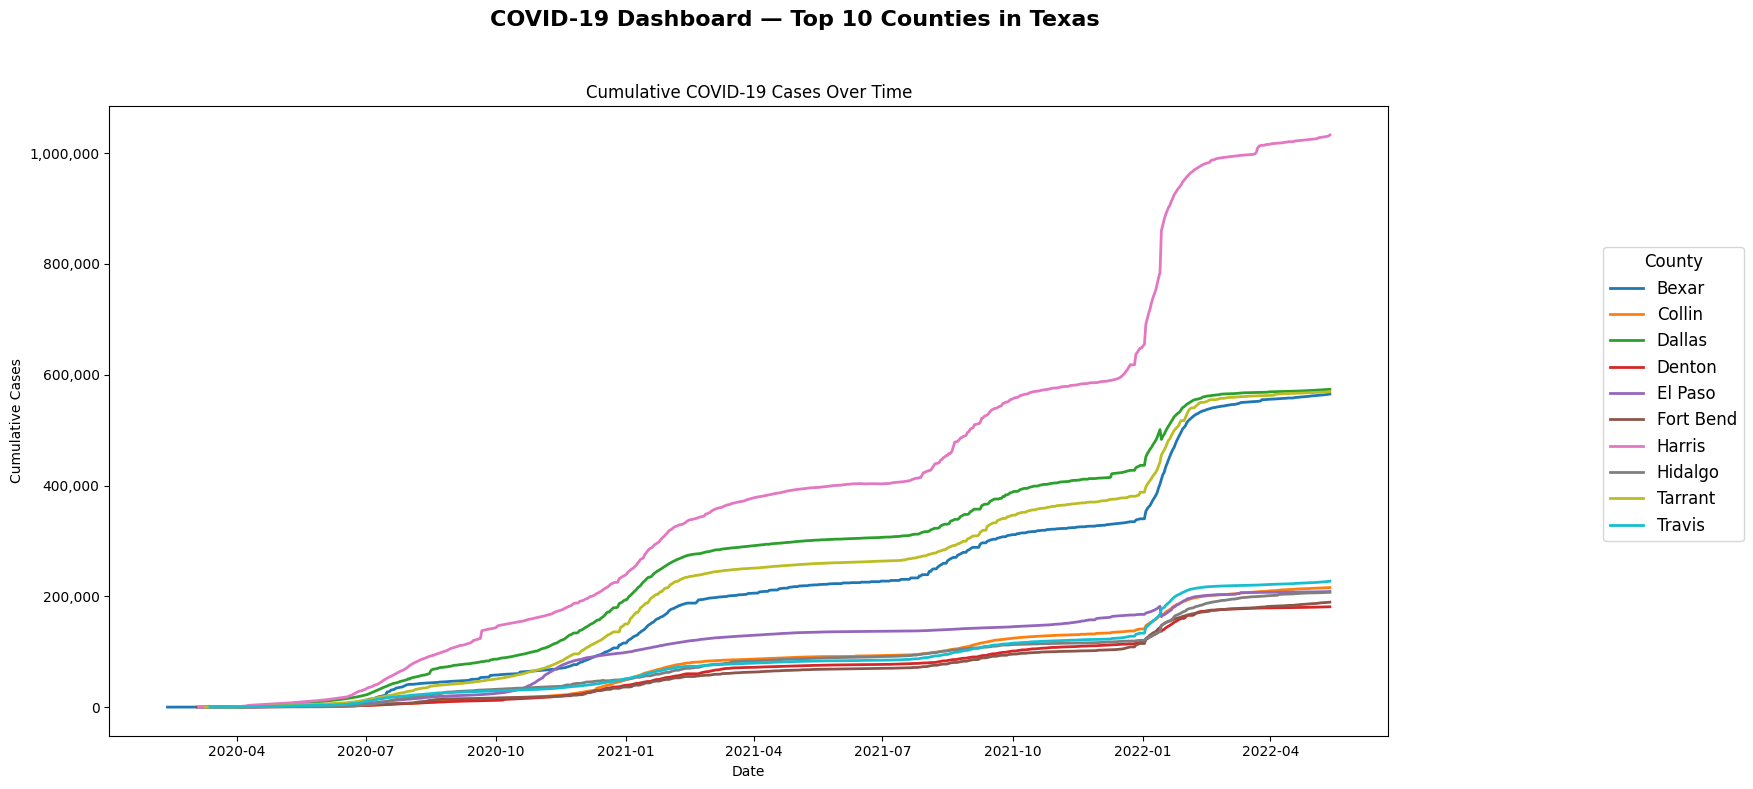

In [4]:
region_sorted = nyt[nyt["state"] == STATE].copy()
region_sorted = region_sorted.sort_values(["county", "date"])

print(f"Date range : {region_sorted['date'].min().date()} → {region_sorted['date'].max().date()}")
print(f"{STATE} rows : {len(region_sorted):,}")
print(f"Counties   : {region_sorted['county'].nunique()}")

top_counties = region_sorted.groupby("county")["cases"].max().nlargest(10).index
print(f"Top 10 counties: {list(top_counties)}")

df_top = region_sorted[region_sorted["county"].isin(top_counties)].copy()

pivot_cumulative = (
    df_top.pivot(index="date", columns="county", values="cases")
          .sort_index()
)

fig, ax1 = plt.subplots(figsize=(16, 8))
fig.suptitle(
    f"COVID-19 Dashboard — Top 10 Counties in {STATE}",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

# Plot — Cumulative cases
for county in pivot_cumulative.columns:
    ax1.plot(pivot_cumulative.index, pivot_cumulative[county], linewidth=2, label=county)

ax1.set_ylabel("Cumulative Cases")
ax1.set_xlabel("Date")
ax1.set_title("Cumulative COVID-19 Cases Over Time")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="County",
    bbox_to_anchor=(1, 0.5),
    loc="center left",
    fontsize=12,
    title_fontsize=12,
)

plt.tight_layout(rect=[0, 0, 0.88, 0.95])
plt.show()

## 1.3. Load Census Boundaries & Centroid Extraction

Each county is represented by a polygon $P_i \subset \mathbb{R}^2$ obtained from the county boundary dataset. To assign a spatial location to each county, we compute the **centroid** of the polygon:

$$ (x_i,y_i)=\left(\frac{1}{|P_i|}\int_{P_i}x\,dA,\; 
\frac{1}{|P_i|}\int_{P_i}y\,dA\right)$$

where $P_i$ is the area of the county.

The centroid is first computed in a projected coordinate system ($EPSG:3857$) for geometric accuracy, then converted back to geographic coordinates ($EPSG:4326$) to obtain the county **longitude** and **latitude**: $ (\text{clon}_i,\ \text{clat}_i) $

In [5]:
kml_path = "/Users/atalha/Desktop/Neumann_ADI/Neumann/geo_data/cb_2023_us_county_500k.kml"
counties = gpd.read_file(kml_path).to_crs(epsg=4326)
counties["GEOID"] = counties["GEOID"].astype(str).str.zfill(5)

region_count = counties[counties["GEOID"].isin(set(region_nyt["fips"].unique()))].copy()
print(f"{STATE} counties matched to map shapes: {len(region_count)}")

rc_proj = region_count.to_crs(epsg=3857)
cent = rc_proj.geometry.centroid
cent_wgs = gpd.GeoSeries(cent, crs=3857).to_crs(epsg=4326)
region_count["clon"] = cent_wgs.x
region_count["clat"] = cent_wgs.y
print(f"\nSample county centroids:\n")
print(region_count[["GEOID","Name","clon","clat"]].sample(6).to_string(index=False))

Texas counties matched to map shapes: 254

Sample county centroids:

GEOID          Name        clon      clat
48157     Fort Bend  -95.770965 29.527720
48173     Glasscock -101.520780 31.869733
48031        Blanco  -98.399864 30.266677
48445         Terry -102.335163 33.174069
48405 San Augustine  -94.168198 31.394546
48027          Bell  -97.478759 31.037550


In [6]:
def date_range_from_dates(dates):
    d0 = pd.to_datetime(min(dates))
    d1 = pd.to_datetime(max(dates))
    return pd.date_range(d0, d1, freq="D")

all_days = date_range_from_dates(DATES)
print(f"Days to process: {len(all_days)} ({all_days[0].date()} → {all_days[-1].date()})")

region_nyt = region_nyt.sort_values(["fips", "date"])
region_nyt["cases"] = region_nyt["cases"].fillna(0.0)

print(f"\nSample showing cumulative vs daily_new for Dallas County:")
king = region_nyt[region_nyt["county"] == "Dallas"][["date","cases"]]
king = king[(king["date"] >= "2021-03-27") & (king["date"] <= "2021-04-10")]
print(king.to_string(index=False))

Days to process: 682 (2020-07-01 → 2022-05-13)

Sample showing cumulative vs daily_new for Dallas County:
      date  cases
2021-03-27 290108
2021-03-28 290108
2021-03-29 290617
2021-03-30 290898
2021-03-31 291262
2021-04-01 291589
2021-04-02 291859
2021-04-03 292153
2021-04-04 292153
2021-04-05 292364
2021-04-06 292743
2021-04-07 293121
2021-04-08 293150
2021-04-09 293659
2021-04-10 293934


## 1.4. Computational Grid Construction

Let the region bounding box be
$
[\lambda_{\min},\lambda_{\max}] \times [\phi_{\min},\phi_{\max}],
$
with padding $\delta$ added to each boundary.

A uniform grid with $N_x \times N_y$ points is generated using

$$
\lambda_j = \lambda_{\min} + j\frac{\lambda_{\max}-\lambda_{\min}}{N_x-1}, 
\quad j=0,\dots,N_x-1
$$

$$
\phi_k = \phi_{\min} + k\frac{\phi_{\max}-\phi_{\min}}{N_y-1}, 
\quad k=0,\dots,N_y-1
$$

The computational mesh is $(\text{Lon},\text{Lat}) = \{(\lambda_j,\phi_k)\}$


## 2.1. Scattered County Data to Continuous Surface

## RBF Interpolation

**Goal:** Find weights $w_i$ such that the interpolant exactly passes through all data points.

The interpolant is:

$$\hat{f}(\mathbf{x}) = \sum_{i=1}^{N} w_i \, \phi\left(\|\mathbf{x} - \mathbf{x}_i\|\right)$$

With the **Gaussian kernel**:

$$\phi(r) = \exp\left(-(\varepsilon r)^2\right)$$

where $r = \|\mathbf{x} - \mathbf{x}_i\|$ is the Euclidean distance and $\varepsilon$ is the fixed shape parameter.

**Solving for weights** requires building the system:

$$\underbrace{\begin{bmatrix} \phi(r_{11}) & \cdots & \phi(r_{1N}) \\ \vdots & \ddots & \vdots \\ \phi(r_{N1}) & \cdots & \phi(r_{NN}) \end{bmatrix}}_{\Phi} \begin{bmatrix} w_1 \\ \vdots \\ w_N \end{bmatrix} = \begin{bmatrix} y_1 \\ \vdots \\ y_N \end{bmatrix}$$

Solved as $\mathbf{w} = \Phi^{-1} \mathbf{y}$, then prediction at new point $\mathbf{x}^*$:

$$\hat{f}(\mathbf{x}^*) = \sum_{i=1}^{N} w_i \exp\left(-\varepsilon^2 \|\mathbf{x}^* - \mathbf{x}_i\|^2\right)$$


In [27]:
# def build_grid(lon_min, lon_max, lat_min, lat_max, nx, ny):
#     lons = np.linspace(lon_min, lon_max, nx)
#     lats = np.linspace(lat_min, lat_max, ny)
#     Lon, Lat = np.meshgrid(lons, lats, indexing="xy")
#     return Lon, Lat

# NX, NY = 80, 80
# BBOX_PADDING_DEG = 0.5   

# lon_min, lat_min, lon_max, lat_max = region_count.total_bounds
# lon_min -= BBOX_PADDING_DEG;  lon_max += BBOX_PADDING_DEG
# lat_min -= BBOX_PADDING_DEG;  lat_max += BBOX_PADDING_DEG

# Lon, Lat = build_grid(lon_min, lon_max, lat_min, lat_max, NX, NY)
# print(f"Bounding box: lon [{lon_min:.2f}, {lon_max:.2f}], lat [{lat_min:.2f}, {lat_max:.2f}]")
# print(f"Grid shape  : {Lon.shape}")

# cum_raw = {}
# county_pts = {}

# for day in all_days:
    
#     df_day = region_nyt[region_nyt["date"] == day][["fips", "cases"]].copy()
#     tmp = region_count[["GEOID", "clon", "clat"]].merge(df_day, left_on="GEOID", right_on="fips", how="left")
#     tmp["cases"] = tmp["cases"].fillna(0.0)
    
#     lon_pts = tmp["clon"].to_numpy(float)
#     lat_pts = tmp["clat"].to_numpy(float)
#     val = tmp["cases"].to_numpy(float)

#     rbf = Rbf(lon_pts, lat_pts, val, function="gaussian", epsilon=0.25)
#     grid_cum = np.maximum(rbf(Lon, Lat), 0) 

#     ds = day.strftime("%Y-%m-%d")
#     cum_raw[ds] = grid_cum
#     county_pts[ds] = (lon_pts, lat_pts, val)

# plot_dates = ["2021-01-01", "2022-01-01"]

# raw_vals = np.concatenate([county_pts[ds][2] for ds in plot_dates])
# grid_vals = np.concatenate([cum_raw[ds].ravel() for ds in plot_dates])

# vmax_raw = np.percentile(raw_vals, 99)
# vmax_grid = np.percentile(grid_vals, 99)

# fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# for j, ds in enumerate(plot_dates):
#     x, y, v = county_pts[ds]
#     sc = ax[0, j].scatter(x, y, c=v, cmap="YlOrRd", s=20, vmin=0, vmax=vmax_raw)
#     ax[0, j].set_title(f"Raw county data — {ds}")
#     ax[0, j].set_xlabel("Longitude")
#     ax[0, j].set_ylabel("Latitude")
#     fig.colorbar(sc, ax=ax[0, j])

#     im = ax[1, j].imshow(cum_raw[ds], origin="lower",
#                          extent=[lon_min, lon_max, lat_min, lat_max],
#                          cmap="YlOrRd", aspect="auto", vmin=0, vmax=vmax_grid)
    
#     ax[1, j].set_title(f"RBF interpolated — {ds}")
#     ax[1, j].set_xlabel("Longitude")
#     ax[1, j].set_ylabel("Latitude")
#     fig.colorbar(im, ax=ax[1, j])

# plt.tight_layout()
# plt.show()

## Gaussian Process Regression

**Goal:** Model $f(\mathbf{x})$ as a random function with a prior, then condition on observed data.

**Prior:**

$$f(\mathbf{x}) \sim \mathcal{GP}\left(0,\; k(\mathbf{x}, \mathbf{x}')\right)$$

With the **RBF kernel**:

$$k(\mathbf{x}, \mathbf{x}') = \exp\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2}\right)$$

where $\ell$ is the **length scale** — learned from data, not fixed.

**Observation model** (with noise $\alpha$):

$$y_i = f(\mathbf{x}_i) + \varepsilon_i, \quad \varepsilon_i \sim \mathcal{N}(0, \alpha)$$

**Posterior prediction** at new point $\mathbf{x}^*$:

$$\hat{f}(\mathbf{x}^*) = \mathbf{k}_*^T \left(K + \alpha I\right)^{-1} \mathbf{y}$$

$$\text{Var}\left[\hat{f}(\mathbf{x}^*)\right] = k(\mathbf{x}^*, \mathbf{x}^*) - \mathbf{k}_*^T (K + \alpha I)^{-1} \mathbf{k}_*$$

where:
- $K_{ij} = k(\mathbf{x}_i, \mathbf{x}_j)$ — the $N \times N$ kernel matrix between training points
- $\mathbf{k}_* = [k(\mathbf{x}^*, \mathbf{x}_1), \ldots, k(\mathbf{x}^*, \mathbf{x}_N)]^T$ — kernel vector between test point and training points

**Length scale is learned** by maximizing the log marginal likelihood:

$$\log p(\mathbf{y} \mid X, \ell) = -\frac{1}{2}\mathbf{y}^T(K+\alpha I)^{-1}\mathbf{y} - \frac{1}{2}\log|K + \alpha I| - \frac{N}{2}\log 2\pi$$


Bounding box: lon [-107.15, -93.01], lat [25.34, 37.00]
Grid shape  : (80, 80)


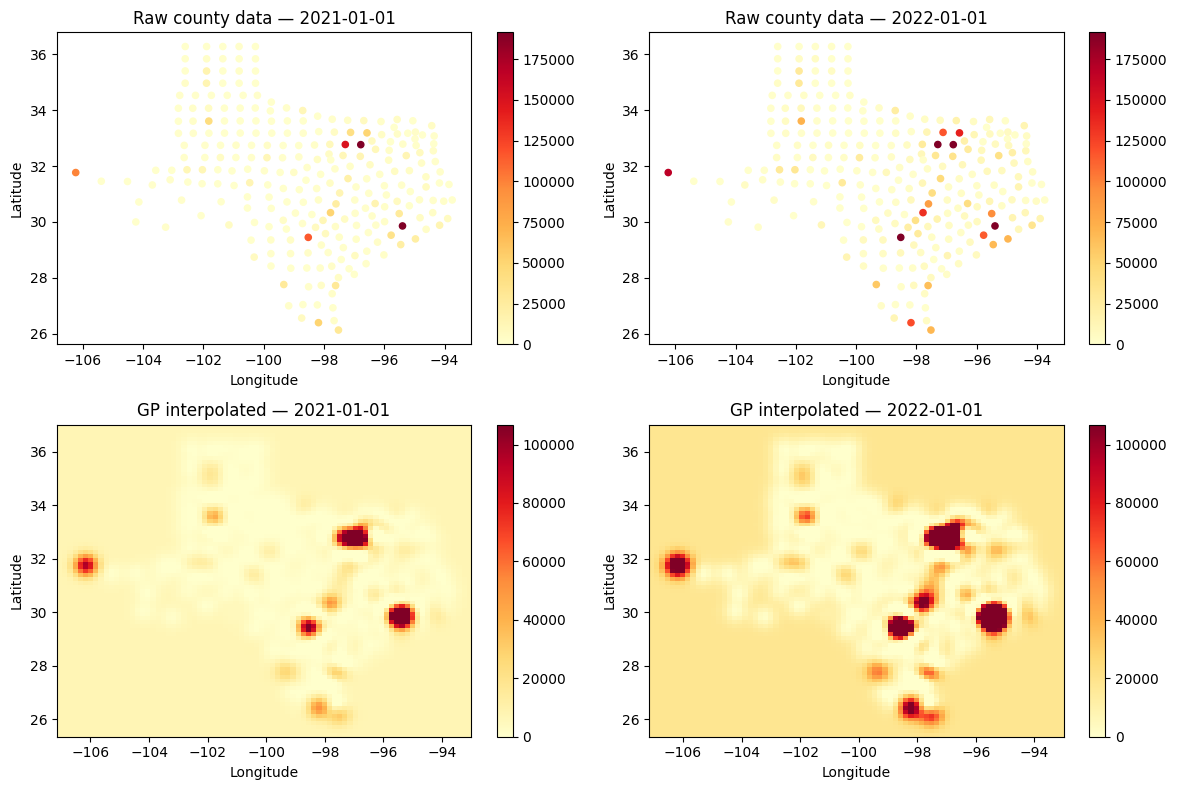

In [7]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

def build_grid(lon_min, lon_max, lat_min, lat_max, nx, ny):
    lons = np.linspace(lon_min, lon_max, nx)
    lats = np.linspace(lat_min, lat_max, ny)
    Lon, Lat = np.meshgrid(lons, lats, indexing="xy")
    return Lon, Lat

NX, NY = 80, 80
BBOX_PADDING_DEG = 0.5   

lon_min, lat_min, lon_max, lat_max = region_count.total_bounds
lon_min -= BBOX_PADDING_DEG;  lon_max += BBOX_PADDING_DEG
lat_min -= BBOX_PADDING_DEG;  lat_max += BBOX_PADDING_DEG

Lon, Lat = build_grid(lon_min, lon_max, lat_min, lat_max, NX, NY)
print(f"Bounding box: lon [{lon_min:.2f}, {lon_max:.2f}], lat [{lat_min:.2f}, {lat_max:.2f}]")
print(f"Grid shape  : {Lon.shape}")

cum_raw = {}
county_pts = {}

for day in all_days:
    df_day = region_nyt[region_nyt["date"] == day][["fips", "cases"]].copy()
    tmp = region_count[["GEOID", "clon", "clat"]].merge(df_day, left_on="GEOID", right_on="fips", how="left")
    tmp["cases"] = tmp["cases"].fillna(0.0)

    lon_pts = tmp["clon"].to_numpy(float)
    lat_pts = tmp["clat"].to_numpy(float)
    val     = tmp["cases"].to_numpy(float)

    X = np.c_[lon_pts, lat_pts]

    kernel = RBF(length_scale=0.5, length_scale_bounds=(0.1, 5.0))

    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, alpha=1e-3)
    gp.fit(X, val)

    grid_pred = gp.predict(np.c_[Lon.ravel(), Lat.ravel()]).reshape(Lon.shape)
    grid_cum = np.maximum(grid_pred, 0)
  
    ds = day.strftime("%Y-%m-%d")
    cum_raw[ds]    = grid_cum
    county_pts[ds] = (lon_pts, lat_pts, val)

plot_dates = ["2021-01-01", "2022-01-01"]

raw_vals = np.concatenate([county_pts[ds][2] for ds in plot_dates])
grid_vals = np.concatenate([cum_raw[ds].ravel() for ds in plot_dates])


vmax_raw = np.percentile(raw_vals, 99)
vmax_grid = np.percentile(grid_vals, 99)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for j, ds in enumerate(plot_dates):
    x, y, v = county_pts[ds]
    sc = ax[0, j].scatter(x, y, c=v, cmap="YlOrRd", s=20, vmin=0, vmax=vmax_raw)
    ax[0, j].set_title(f"Raw county data — {ds}")
    ax[0, j].set_xlabel("Longitude")
    ax[0, j].set_ylabel("Latitude")
    fig.colorbar(sc, ax=ax[0, j])

    im = ax[1, j].imshow(cum_raw[ds], origin="lower",
                         extent=[lon_min, lon_max, lat_min, lat_max],
                         cmap="YlOrRd", aspect="auto", vmin=0, vmax=vmax_grid)
    
    ax[1, j].set_title(f"GP interpolated — {ds}")
    ax[1, j].set_xlabel("Longitude")
    ax[1, j].set_ylabel("Latitude")
    fig.colorbar(im, ax=ax[1, j])

plt.tight_layout()
plt.show()

  Date          Raw cumulative max  Normalize cumulative max
  --------------------------------------------------------------------
  2020-07-01              30989.59               0.03
  2021-01-01             227519.41               0.23
  2021-09-01             478354.69               0.48
  2022-01-01             623280.18               0.63
  2022-05-13             988556.25               1.00


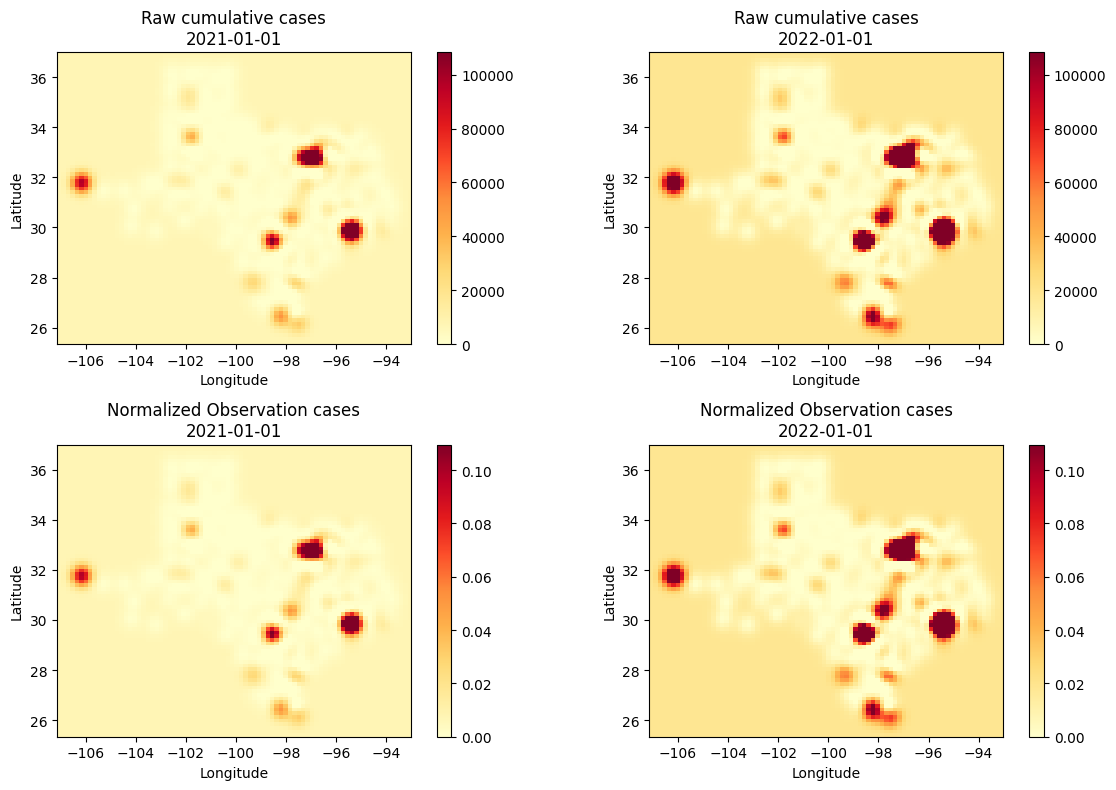

In [8]:
cum_raw = cum_raw
gmax = max(cum_raw[ds].max() for ds in cum_raw)
obs_norm = {ds: cum_raw[ds] / gmax for ds in cum_raw}

print(f"  {'Date':<12}  {'Raw cumulative max':>18}  {'Normalize cumulative max':>16}")
print(f"  {'-'*68}")
for ds in DATES:
    raw_max   = cum_raw[ds].max()
    norm_max  = obs_norm[ds].max()
    print(f"  {ds:<12}  {raw_max:>18.2f}  {norm_max:>17.2f}")

# --------- plot two dates ----------
plot_dates = ["2021-01-01", "2022-01-01"]
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# vmax_raw = np.percentile(cum_raw, 99)
# vmax_norm = np.percentile(obs_norm, 99)

vmax_raw = np.percentile(np.concatenate([cum_raw[ds].ravel() for ds in cum_raw]), 99)
vmax_norm = np.percentile(np.concatenate([obs_norm[ds].ravel() for ds in obs_norm]), 99)

for j, ds in enumerate(plot_dates):
    im0 = ax[0, j].imshow(cum_raw[ds], origin="lower",
                          extent=[lon_min, lon_max, lat_min, lat_max], cmap="YlOrRd", vmin=0, vmax=vmax_raw)
    ax[0, j].set_title(f"Raw cumulative cases\n{ds}")
    ax[0, j].set_xlabel("Longitude"); ax[0, j].set_ylabel("Latitude")
    plt.colorbar(im0, ax=ax[0, j])

    im1 = ax[1, j].imshow(obs_norm[ds], origin="lower",
                          extent=[lon_min, lon_max, lat_min, lat_max], cmap="YlOrRd", vmin=0, vmax=vmax_norm)
    ax[1, j].set_title(f"Normalized Observation cases\n{ds}")
    ax[1, j].set_xlabel("Longitude"); ax[1, j].set_ylabel("Latitude")
    plt.colorbar(im1, ax=ax[1, j])

plt.tight_layout()
plt.show()

## THOMAS Algorithm (Tridiagonal Solver)

In [9]:
def LU_Thomas(a, b, c, r):
    n = len(r)
    w = np.zeros(n, float)  # solution
    l = np.zeros(n, float)  # lower factor
    u = np.zeros(n, float)  # upper factor
    z = np.zeros(n, float)  # intermediate

    # Forward sweep (LU decomposition)
    u[0] = b[0]
    for k in range(1, n):
        l[k] = a[k] / u[k-1]
        u[k] = b[k] - l[k] * c[k-1]

    # Forward substitution (solve L*z = r)
    z[0] = r[0]
    for k in range(1, n):
        z[k] = r[k] - l[k] * z[k-1]

    # Backward substitution (solve U*w = z)
    w[n-1] = z[n-1] / u[n-1]
    for k in range(n-2, -1, -1):
        w[k] = (z[k] - c[k] * w[k+1]) / u[k]

    return w

## ADI Sweep Function

In [10]:
def ADI_sweep(U, coeff, lx, ly, axis, dt):
    U = np.asarray(U, float)
    coeff = np.asarray(coeff, float)
    ny, nx = U.shape
    Uout = np.zeros_like(U)

    if axis == "x":  
        for j in range(ny):
            a = np.zeros(nx); b = np.zeros(nx)
            c = np.zeros(nx); r = np.zeros(nx)

            for i in range(nx):         
                a[i] = -lx if i > 0    else 0.0
                c[i] = -lx if i < nx-1 else 0.0
                b[i] = 1.0 + 2.0*lx + 0.25*dt*coeff[j, i]

                ym = U[j-1, i] if j > 0    else U[1,    i]  # reflect at bottom
                yp = U[j+1, i] if j < ny-1 else U[ny-2, i]  # reflect at top

                # r[i] = (1.0 - 2.0*lx - 0.25*dt*coeff[j, i]) * U[j, i] + ly*(ym + yp)
                r[i] = (1.0 - 2.0*ly - 0.25*dt*coeff[j, i]) * U[j, i] + ly*(ym + yp)

            Uout[j, :] = LU_Thomas(a, b, c, r)

    elif axis == "y":
        for i in range(nx):
            a = np.zeros(ny); b = np.zeros(ny)
            c = np.zeros(ny); r = np.zeros(ny)

            for j in range(ny):
                a[j] = -ly if j > 0    else 0.0
                c[j] = -ly if j < ny-1 else 0.0
                b[j] = 1.0 + 2.0*ly + 0.25*dt*coeff[j, i]

                xm = U[j, i-1] if i > 0    else U[j, 1]     # reflect at left
                xp = U[j, i+1] if i < nx-1 else U[j, nx-2]  # reflect at right

                # r[j] = (1.0 - 2.0*ly - 0.25*dt*coeff[j, i]) * U[j, i] + lx*(xm + xp)
                r[j] = (1.0 - 2.0*lx - 0.25*dt*coeff[j, i]) * U[j, i] + lx*(xm + xp)

            Uout[:, i] = LU_Thomas(a, b, c, r)

    else:
        raise ValueError("axis must be 'x' or 'y'")

    return Uout

# FORWARD SIR MODEL WITH NUDGING

In [11]:
# dt = 0.1
# steps = 10

# lam = 0.6
# dS  = 0.002
# dI  = 0.0005
# kS  = 0.05
# kI  = 0.02
# N = 1.0

# USE_NUDGING = False
# eta = 0.0   
# EPS= 1e-8 

# print("Running forward ADI SIR model with nudging...")
# print(f"   Parameters: kS={kS}, kI={kI}, dS={dS}, dI={dI}, eta={eta}")
# print(f"   Time steps: {steps} steps/day × {len(all_days)-1} days = {steps*(len(all_days)-1)} total steps")

# # Grid spacing
# hx = (lon_max - lon_min) / (NX - 1)
# hy = (lat_max - lat_min) / (NY - 1)

# # Diffusion weights
# lxS = (dS * dt) / (2.0 * hx*hx) 
# lyS = (dS * dt) / (2.0 * hy*hy) 
# lxI = (dI * dt) / (2.0 * hx*hx) 
# lyI = (dI * dt) / (2.0 * hy*hy) 

# print(f"\nGrid spacing : hx={hx:.4f}°, hy={hy:.4f}°")
# print(f"Diffusion weights: lxS={lxS:.4f}, lyS={lyS:.4f}, lxI={lxI:.4f}, lyI={lyI:.4f}")

# # --- Initialize S and I on day 0 ---
# start = min(DATES)
# I0 = obs_norm[start]
# I = 0.1 * I0
# # I=I0
# S = np.clip(N - I, 0.0, N) 

# print(f"\n   Initial state on {start}:")
# print(f"   I: min={I.min():.4f}, max={I.max():.4f}, mean={I.mean():.4f}")
# print(f"   S: min={S.min():.4f}, max={S.max():.4f}, mean={S.mean():.4f}")

# pred_I_raw = {start: I.copy()}
# # pred_I_norm = {start: I.copy()}
# daily_stats = []  

# # --- Main time loop ---
# print(f"\nSimulating day by day...")
# for day_idx, day in enumerate(all_days[1:]):
#     ds = day.strftime("%Y-%m-%d")

#     for _ in range(steps):

#         # I equation: I_t = -k_I*(lam - S)*I + dI*ΔI 
#         coeff_I = kI*(lam - S)
#         Istar = ADI_sweep(I, coeff_I, lxI, lyI, axis="x", dt=dt)
#         Inew  = ADI_sweep(Istar, coeff_I, lxI, lyI, axis="y", dt=dt)
#         I     = np.maximum(Inew, 0.0)

#         # S equation: S_t = - k_S*I*S + dS*ΔS 
#         coeff_S = kS*I
#         Sstar = ADI_sweep(S, coeff_S, lxS, lyS, axis="x", dt=dt)
#         Snew  = ADI_sweep(Sstar, coeff_S, lxS, lyS, axis="y", dt=dt)
#         S     = np.maximum(Snew, 0.0)

#         total = S + I
#         mask  = total > N
#         if np.any(mask):
#             scale = N / (total[mask] + EPS)
#             S[mask] *= scale
#             I[mask] *= scale

#         if USE_NUDGING and eta > 0:
            
#             I_obs = obs_norm[ds]
#             I     = (1.0 - eta) * I + eta * I_obs   
#             I     = np.maximum(I, 0.0)
#             S = np.clip(S, 0.0, N)
            
#             total = S + I
#             mask  = total > N
#             if np.any(mask):
#                 scale = N / (total[mask] + EPS)
#                 S[mask] *= scale
#                 I[mask] *= scale

#     daily_stats.append({
#         "date"   : ds,
#         "I_mean" : float(I.mean()),
#         "S_mean" : float(S.mean()),
#         "SI_mean": float((S + I).mean()) 
#     })
    
#     if ds in set(DATES):
#         pred_I_raw[ds] = I.copy()
#         print(f"Date: {ds} | I mean={I.mean():.4f}, max={I.max():.4f}")
        
#     gmax_model = max(pred_I_raw[d].max() for d in pred_I_raw)
#     pred_I_norm = {d: pred_I_raw[d] / (gmax_model + EPS) for d in pred_I_raw}

In [32]:
dt = 0.1
steps = 10

# lam = 0.0
# dS  = 0.0005
# dI  = 0.0001
# kS  = 0.008 
# kI  = 0.008
# N = 1.0

lam = 0.01
dS  = 0.002
dI  = 0.0005
kS  = 0.05
kI  = 0.02
N = 1.0

USE_NUDGING = False
eta = 0.0   
EPS= 1e-8 

print("Running forward ADI SIR model with nudging...")
print(f"   Parameters: kS={kS}, kI={kI}, dS={dS}, dI={dI}, eta={eta}")
print(f"   Time steps: {steps} steps/day × {len(all_days)-1} days = {steps*(len(all_days)-1)} total steps")

# Grid spacing
hx = (lon_max - lon_min) / (NX - 1)
hy = (lat_max - lat_min) / (NY - 1)

# Diffusion weights
lxS = (dS * dt) / (2.0 * hx*hx) 
lyS = (dS * dt) / (2.0 * hy*hy) 
lxI = (dI * dt) / (2.0 * hx*hx) 
lyI = (dI * dt) / (2.0 * hy*hy) 

print(f"\nGrid spacing : hx={hx:.4f}°, hy={hy:.4f}°")
print(f"Diffusion weights: lxS={lxS:.4f}, lyS={lyS:.4f}, lxI={lxI:.4f}, lyI={lyI:.4f}")

# --- Initialize S and I on day 0 ---
start = min(DATES)
I0 = obs_norm[start]
I = 0.1 * I0
# I=I0
S = np.clip(N - I, 0.0, N) 

print(f"\n   Initial state on {start}:")
print(f"   I: min={I.min():.4f}, max={I.max():.4f}, mean={I.mean():.4f}")
print(f"   S: min={S.min():.4f}, max={S.max():.4f}, mean={S.mean():.4f}")

pred_I_raw = {start: I.copy()}
# pred_I_norm = {start: I.copy()}
daily_stats = []  

# --- Main time loop ---
print(f"\nSimulating day by day...")
for day_idx, day in enumerate(all_days[1:]):
    ds = day.strftime("%Y-%m-%d")

    for _ in range(steps):

        # I equation: I_t = -k_I*(lam - S)*I + dI*ΔI 
        coeff_I = kI*(lam - S)
        Istar = ADI_sweep(I, coeff_I, lxI, lyI, axis="x", dt=dt)
        Inew  = ADI_sweep(Istar, coeff_I, lxI, lyI, axis="y", dt=dt)
        I     = np.maximum(Inew, 0.0)

        # S equation: S_t = - k_S*I*S + dS*ΔS 
        coeff_S = kS*I
        Sstar = ADI_sweep(S, coeff_S, lxS, lyS, axis="x", dt=dt)
        Snew  = ADI_sweep(Sstar, coeff_S, lxS, lyS, axis="y", dt=dt)
        S     = np.maximum(Snew, 0.0)

        total = S + I
        mask  = total > N
        if np.any(mask):
            scale = N / (total[mask] + EPS)
            S[mask] *= scale
            I[mask] *= scale

        if USE_NUDGING and eta > 0:
            
            I_obs = obs_norm[ds]
            I     = (1.0 - eta) * I + eta * I_obs   
            I     = np.maximum(I, 0.0)
            S = np.clip(S, 0.0, N)
            
            total = S + I
            mask  = total > N
            if np.any(mask):
                scale = N / (total[mask] + EPS)
                S[mask] *= scale
                I[mask] *= scale

    daily_stats.append({
        "date"   : ds,
        "I_mean" : float(I.mean()),
        "S_mean" : float(S.mean()),
        "SI_mean": float((S + I).mean()) 
    })

    pred_I_raw[ds] = I.copy()        
    gmax_model = max(pred_I_raw[d].max() for d in pred_I_raw)
    pred_I_norm = {d: pred_I_raw[d] / (gmax_model + EPS) for d in pred_I_raw}

Running forward ADI SIR model with nudging...
   Parameters: kS=0.05, kI=0.02, dS=0.002, dI=0.0005, eta=0.0
   Time steps: 10 steps/day × 681 days = 6810 total steps

Grid spacing : hx=0.1790°, hy=0.1476°
Diffusion weights: lxS=0.0031, lyS=0.0046, lxI=0.0008, lyI=0.0011

   Initial state on 2020-07-01:
   I: min=0.0000, max=0.0031, mean=0.0001
   S: min=0.9969, max=1.0000, mean=0.9999

Simulating day by day...


## VALIDATION & PLOTS

Number of common dates: 682
Date range: 2020-07-01 00:00:00 to 2022-05-13 00:00:00
Top 6 counties: ['Harris', 'Dallas', 'Tarrant', 'Bexar', 'Travis', 'Collin']


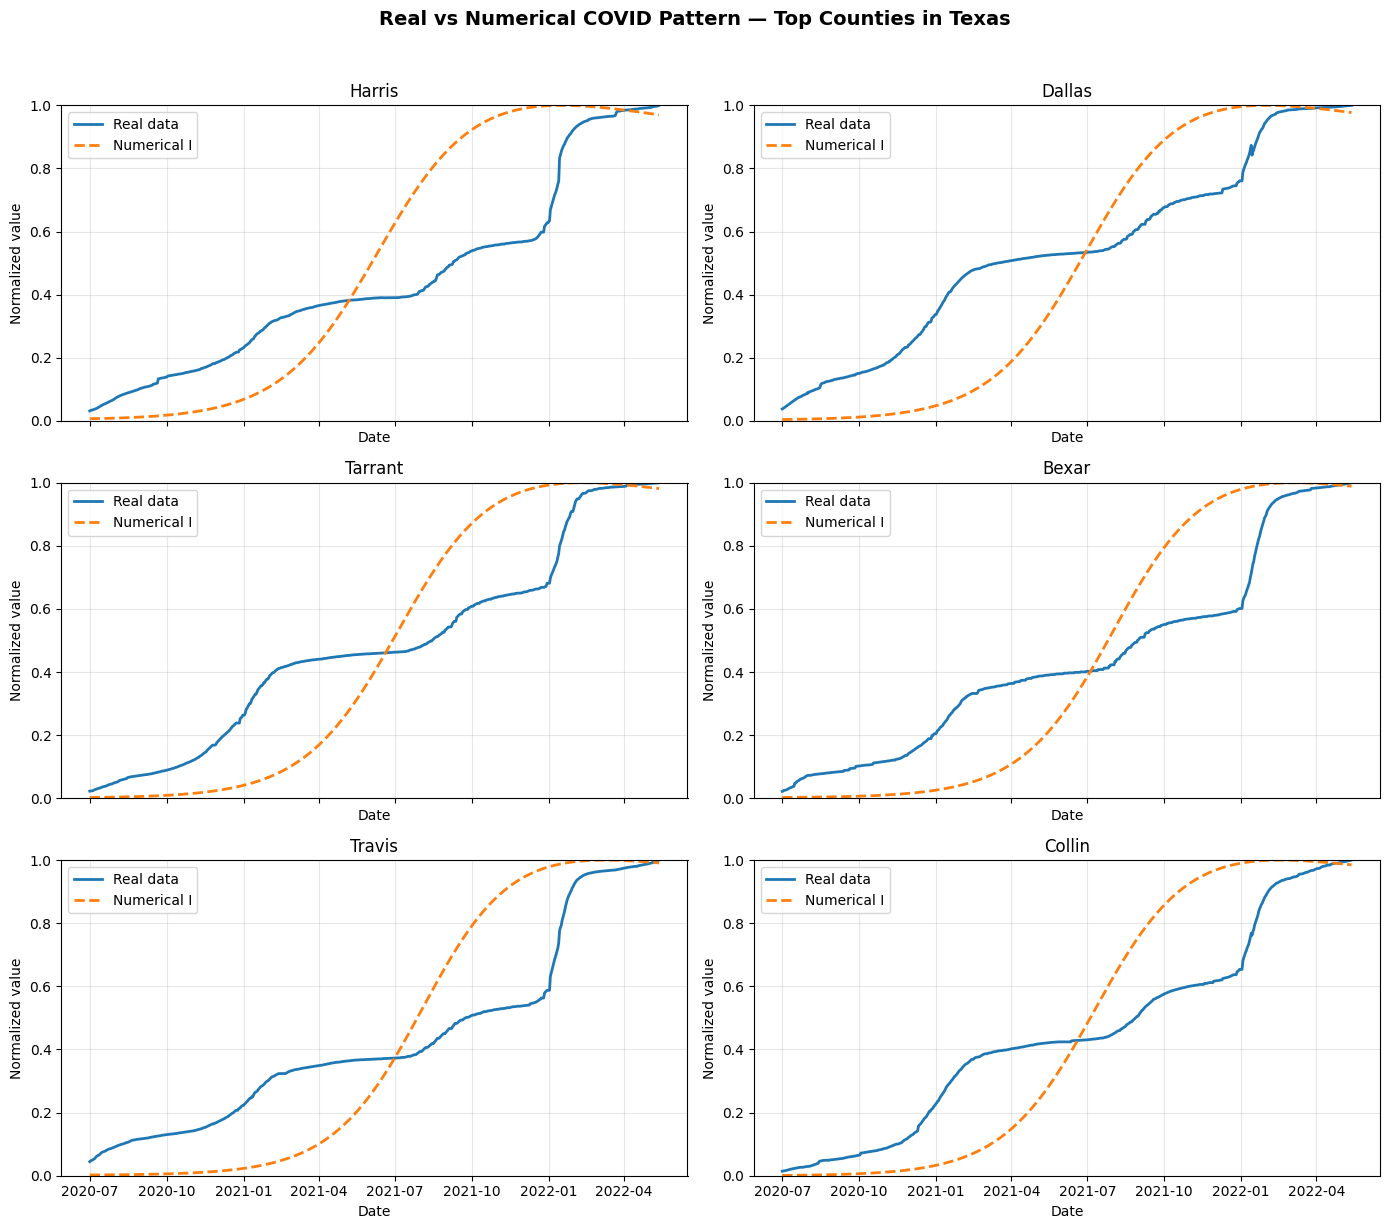


County-wise comparison:
 county     rmse     corr
  Bexar 0.192278 0.910741
 Collin 0.195341 0.906532
Tarrant 0.196398 0.903004
 Dallas 0.203044 0.909853
 Travis 0.206108 0.895823
 Harris 0.223474 0.876191


In [34]:
def county_grid(grid2d, Lon, Lat, x_c, y_c):
    dist = (Lon - x_c)**2 + (Lat - y_c)**2
    iy, ix = np.unravel_index(np.argmin(dist), dist.shape)
    return grid2d[iy, ix]

num_dates = pd.to_datetime(sorted(pred_I_norm.keys()))
real_dates = pd.to_datetime(region_sorted["date"].unique())

common_dates = sorted(set(num_dates).intersection(set(real_dates)))

print("Number of common dates:", len(common_dates))
print("Date range:", common_dates[0], "to", common_dates[-1])


real_data = region_sorted[region_sorted["date"].isin(common_dates)].copy()
pivot_real = (real_data.pivot(index="date", columns="county", values="cases").sort_index())
real_norm = pivot_real.divide(pivot_real.max(axis=0).replace(0, np.nan), axis=1)

top_cnty = region_sorted.groupby("county")["cases"].max().nlargest(6).index
print("Top 6 counties:", list(top_cnty))
top_cnty_list = list(top_cnty)

county_lookup = region_count.set_index("Name")[["clon", "clat"]]
num_data = {}

for c in top_cnty_list:
    
    x_c = county_lookup.loc[c, "clon"]
    y_c = county_lookup.loc[c, "clat"]

    series = []
    for ds in common_dates:
        ds_key = pd.Timestamp(ds).strftime("%Y-%m-%d")   
        val = county_grid(pred_I_norm[ds_key], Lon, Lat, x_c, y_c)
        series.append(val)

    num_data[c] = series

pivot_num = pd.DataFrame(num_data, index=pd.to_datetime(common_dates)).sort_index()
num_norm = pivot_num.divide(pivot_num.max(axis=0).replace(0, np.nan), axis=1)
# num_norm = pivot_num.copy()
common_counties = [c for c in num_norm.columns if c in real_norm.columns]

n = len(common_counties)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows), sharex=True)
axes = np.array(axes).reshape(-1)

for k, county in enumerate(common_counties):
    ax = axes[k]

    ax.plot(
        real_norm.index,
        real_norm[county],
        linewidth=2,
        label="Real data"
    )

    ax.plot(
        num_norm.index,
        num_norm[county],
        linewidth=2,
        linestyle="--",
        label="Numerical I"
    )

    ax.set_title(county)
    ax.set_xlabel("Date")
    ax.set_ylabel("Normalized value")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle(
    f"Real vs Numerical COVID Pattern — Top Counties in {STATE}",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.savefig("real_vs_numerical_counties.png", dpi=300, bbox_inches="tight")
plt.show()

rows = []

for county in common_counties:
    y_true = real_norm[county].reindex(num_norm.index).values
    y_pred = num_norm[county].values

    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[valid]
    y_pred = y_pred[valid]

    rmse_val = np.sqrt(np.mean((y_true - y_pred)**2))

    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        corr_val = np.nan
    else:
        corr_val = np.corrcoef(y_true, y_pred)[0, 1]

    rows.append({
        "county": county,
        "rmse": rmse_val,
        "corr": corr_val
    })

compare_df = pd.DataFrame(rows).sort_values(["rmse", "corr"], ascending=[True, False])

print("\nCounty-wise comparison:")
print(compare_df.to_string(index=False))